# Healthcare NLP Pipeline — Proof of Results
**Cambrian College — AI Program**

| Task | Model | Primary Metric |
|------|-------|----------------|
| Task 1 — Sentiment Classification | LinearSVC (TF-IDF) | F1 Macro = 0.8608 |
| Task 2 — Theme Classification | Logistic Regression Multinomial (TF-IDF) | F1 Macro = 0.9071 |
| Task 3 — NMF Topic Modeling | NMF (TF-IDF) | Reconstruction Error = 226.02 |

## 0. Setup & Imports

In [1]:
import sys, os, warnings
sys.path.insert(0, os.path.abspath('..'))
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import NMF
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score, precision_score,
    roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)

print('All imports OK')

All imports OK


## 1. Load Dataset

In [2]:
df = pd.read_csv('../data/patient_feedback.csv')
print(f'Rows: {df.shape[0]:,} | Columns: {df.shape[1]}')
df.head(3)

Rows: 66,657 | Columns: 4


,Feedback,Sentiment,Theme,Satisfaction
0,"""I used to take another oral contraceptive, wh...",0,Birth Control,2.5
1,"""This is my first time using any form of birth...",1,Birth Control,4.0
2,"""I had been on the pill for many years. When m...",1,Birth Control,4.0


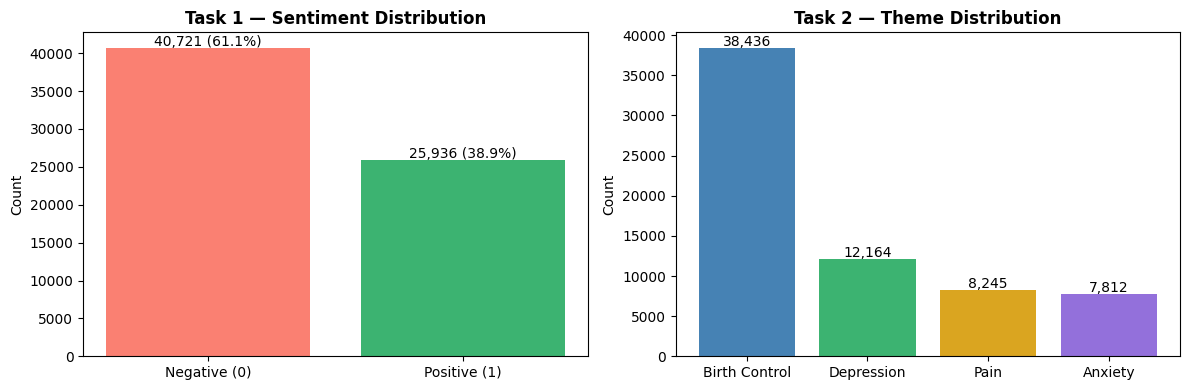

In [ ]:
# --- Colors used throughout the notebook ---
# Sentiment
COLOR_NEGATIVE = 'salmon'       # red-ish negative reviews
COLOR_POSITIVE = 'mediumseagreen'  # green  positive reviews

# Themes (one color per medical category)
COLOR_ANXIETY      = 'steelblue'
COLOR_BIRTHCONTROL = 'mediumseagreen'
COLOR_DEPRESSION   = 'goldenrod'
COLOR_PAIN         = 'mediumpurple'

THEME_COLORS = [COLOR_ANXIETY, COLOR_BIRTHCONTROL, COLOR_DEPRESSION, COLOR_PAIN]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Sentiment distribution
sentiment_counts = df['Sentiment'].value_counts()
axes[0].bar(
    ['Negative (0)', 'Positive (1)'],
    sentiment_counts.values,
    color=[COLOR_NEGATIVE, COLOR_POSITIVE]
)
axes[0].set_title('Task 1 — Sentiment Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(sentiment_counts.values):
    axes[0].text(i, v + 200, f'{v:,} ({v/len(df)*100:.1f}%)', ha='center', fontsize=10)

# Theme distribution
theme_counts = df['Theme'].value_counts()
axes[1].bar(theme_counts.index, theme_counts.values, color=THEME_COLORS)
axes[1].set_title('Task 2 — Theme Distribution', fontweight='bold')
axes[1].set_ylabel('Count')
for i, v in enumerate(theme_counts.values):
    axes[1].text(i, v + 200, f'{v:,}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Text Preprocessing & TF-IDF

In [4]:
import re, html, nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text   = html.unescape(str(text))          # fix HTML entities like &#039;
    text   = text.lower()                       # lowercase
    text   = re.sub(r'[^a-z\s]', '', text)     # remove punctuation & numbers
    tokens = [
        lemmatizer.lemmatize(t)
        for t in text.split()
        if t not in stop_words and len(t) > 2  # remove stopwords & short words
    ]
    return ' '.join(tokens)

df = df.dropna(subset=['Feedback', 'Sentiment']).reset_index(drop=True)
df['cleaned_text'] = df['Feedback'].apply(clean_text)
df = df[df['cleaned_text'].str.strip() != ''].reset_index(drop=True)

print(f'Rows after cleaning : {len(df):,}')
print(f'Unique tokens       : {len(set(" ".join(df["cleaned_text"]).split())):,}')

Rows after cleaning : 66,654
Unique tokens       : 26,765


In [5]:
# Split BEFORE fitting TF-IDF — prevents data leakage
X_text      = df['cleaned_text'].values
y_sentiment = df['Sentiment'].values
y_theme     = df['Theme'].values

train_idx, test_idx = train_test_split(
    np.arange(len(df)), test_size=0.2, random_state=42, stratify=y_sentiment
)

X_train_text = X_text[train_idx];  X_test_text = X_text[test_idx]
y_s_train    = y_sentiment[train_idx]; y_s_test = y_sentiment[test_idx]
y_t_train    = y_theme[train_idx];     y_t_test = y_theme[test_idx]

print(f'Train: {len(X_train_text):,} | Test: {len(X_test_text):,}')

Train: 53,323 | Test: 13,331


In [6]:
# Fit TF-IDF on TRAIN only — same matrix shared by all 3 tasks
vectorizer = TfidfVectorizer(
    max_features=10000,   # keep top 10k words
    ngram_range=(1, 2),   # unigrams + bigrams
    min_df=2,             # ignore very rare words
    sublinear_tf=True,    # log normalization
)
X_train = vectorizer.fit_transform(X_train_text)
X_test  = vectorizer.transform(X_test_text)

feature_names = vectorizer.get_feature_names_out()
print(f'Vocabulary size : {len(feature_names):,}')
print(f'Train matrix    : {X_train.shape}')

Vocabulary size : 10,000
Train matrix    : (53323, 10000)


## 3. Task 1 — Sentiment Classification (LinearSVC)

In [7]:
svm = LinearSVC(max_iter=2000, C=1.0)
svm.fit(X_train, y_s_train)
y_pred_s = svm.predict(X_test)

acc_s   = accuracy_score(y_s_test, y_pred_s)
f1_m_s  = f1_score(y_s_test, y_pred_s, average='macro')
rec_neg = recall_score(y_s_test, y_pred_s, pos_label=0)
auc     = roc_auc_score(y_s_test, svm.decision_function(X_test))

print(f'Accuracy    : {acc_s:.4f}')
print(f'F1 Macro    : {f1_m_s:.4f}')
print(f'AUC         : {auc:.4f}')
print(f'Recall (neg): {rec_neg:.4f}  <- primary metric in healthcare')
print()
print(classification_report(y_s_test, y_pred_s, target_names=['Negative', 'Positive']))

Accuracy    : 0.8681
F1 Macro    : 0.8608
AUC         : 0.9327
Recall (neg): 0.8209  <- primary metric in healthcare

              precision    recall  f1-score   support

    Negative       0.84      0.82      0.83      5187
    Positive       0.89      0.90      0.89      8144

    accuracy                           0.87     13331
   macro avg       0.86      0.86      0.86     13331
weighted avg       0.87      0.87      0.87     13331



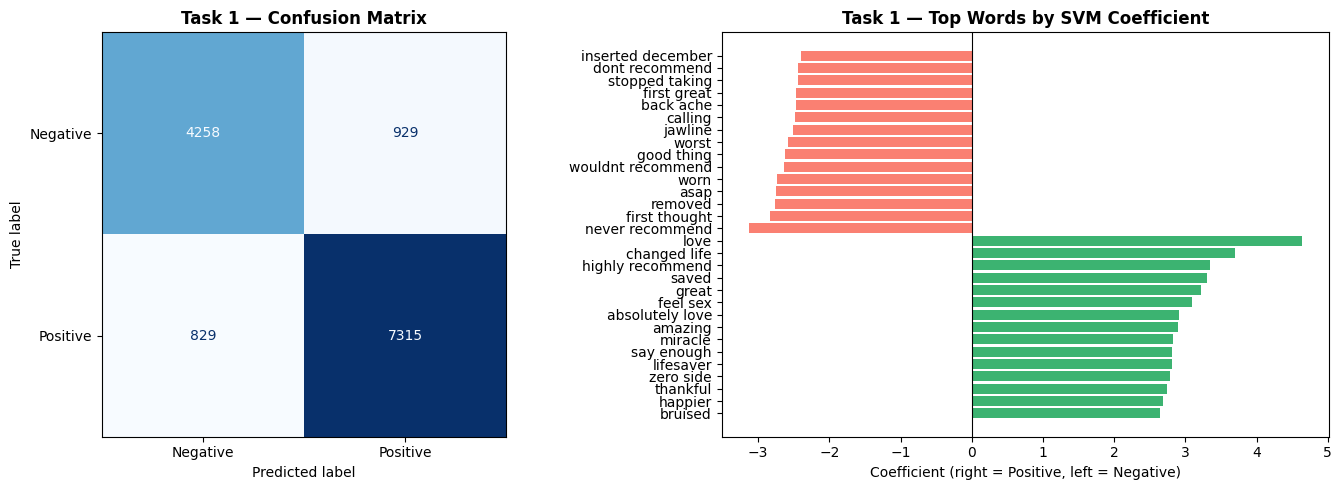

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(y_s_test, y_pred_s)
ConfusionMatrixDisplay(cm, display_labels=['Negative', 'Positive']).plot(
    ax=axes[0], colorbar=False, cmap='Blues'
)
axes[0].set_title('Task 1 — Confusion Matrix', fontweight='bold')

# Top words by SVM coefficient
coefs     = svm.coef_[0]
top_pos   = [feature_names[i] for i in coefs.argsort()[-15:][::-1]]
top_neg   = [feature_names[i] for i in coefs.argsort()[:15]]
vals_pos  = sorted(coefs)[-15:][::-1]
vals_neg  = sorted(coefs)[:15]

axes[1].barh(list(reversed(top_pos)), list(reversed(vals_pos)), color=COLOR_POSITIVE)
axes[1].barh(top_neg, vals_neg, color=COLOR_NEGATIVE)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Task 1 — Top Words by SVM Coefficient', fontweight='bold')
axes[1].set_xlabel('Coefficient (right = Positive, left = Negative)')

plt.tight_layout()
plt.savefig('task1_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Task 2 — Theme Classification (Logistic Regression)

In [9]:
lr = LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs')
lr.fit(X_train, y_t_train)
y_pred_t = lr.predict(X_test)

acc_t  = accuracy_score(y_t_test, y_pred_t)
f1_m_t = f1_score(y_t_test, y_pred_t, average='macro')

print(f'Accuracy : {acc_t:.4f}')
print(f'F1 Macro : {f1_m_t:.4f}')
print()
print(classification_report(y_t_test, y_pred_t, target_names=sorted(set(y_t_test))))

Accuracy : 0.9444
F1 Macro : 0.9071

               precision    recall  f1-score   support

      Anxiety       0.87      0.76      0.81      1622
Birth Control       0.99      1.00      0.99      7678
   Depression       0.85      0.91      0.88      2426
         Pain       0.95      0.94      0.95      1605

     accuracy                           0.94     13331
    macro avg       0.92      0.90      0.91     13331
 weighted avg       0.94      0.94      0.94     13331



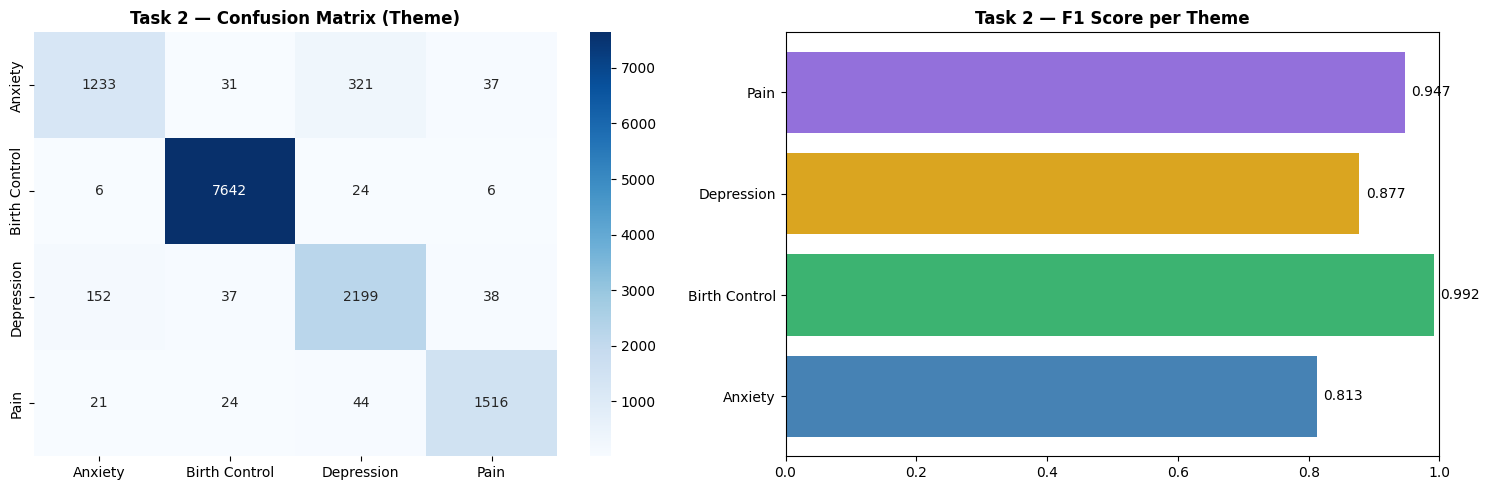

In [10]:
theme_labels = sorted(set(y_t_test))
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Confusion matrix heatmap
cm2 = confusion_matrix(y_t_test, y_pred_t, labels=theme_labels)
sns.heatmap(
    cm2, annot=True, fmt='d', cmap='Blues',
    xticklabels=theme_labels, yticklabels=theme_labels, ax=axes[0]
)
axes[0].set_title('Task 2 — Confusion Matrix (Theme)', fontweight='bold')

# F1 per theme
f1_per_class = f1_score(y_t_test, y_pred_t, average=None, labels=theme_labels)
axes[1].barh(theme_labels, f1_per_class, color=THEME_COLORS)
axes[1].set_xlim(0, 1)
axes[1].set_title('Task 2 — F1 Score per Theme', fontweight='bold')
for i, v in enumerate(f1_per_class):
    axes[1].text(v + 0.01, i, f'{v:.3f}', va='center')

plt.tight_layout()
plt.savefig('task2_theme.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Task 3 — NMF Topic Modeling

In [11]:
nmf = NMF(n_components=4, max_iter=200, random_state=42)
W   = nmf.fit_transform(X_train)
H   = nmf.components_

recon_error = nmf.reconstruction_err_
print(f'Reconstruction error: {recon_error:.4f}')
print()

topics = {}
for i, topic in enumerate(H):
    top_words = [feature_names[j] for j in topic.argsort()[-10:][::-1]]
    topics[f'Topic {i+1}'] = top_words
    print(f'Topic {i+1}: {", ".join(top_words)}')

Reconstruction error: 226.0206

Topic 1: period, month, birth, pill, control, birth control, ive, weight, first, got
Topic 2: anxiety, depression, feel, life, taking, day, take, like, attack, medication
Topic 3: pain, back, work, take, relief, hour, back pain, day, medicine, doctor
Topic 4: effect, side effect, side, experienced, nausea, negative, bad side, great, far, negative side


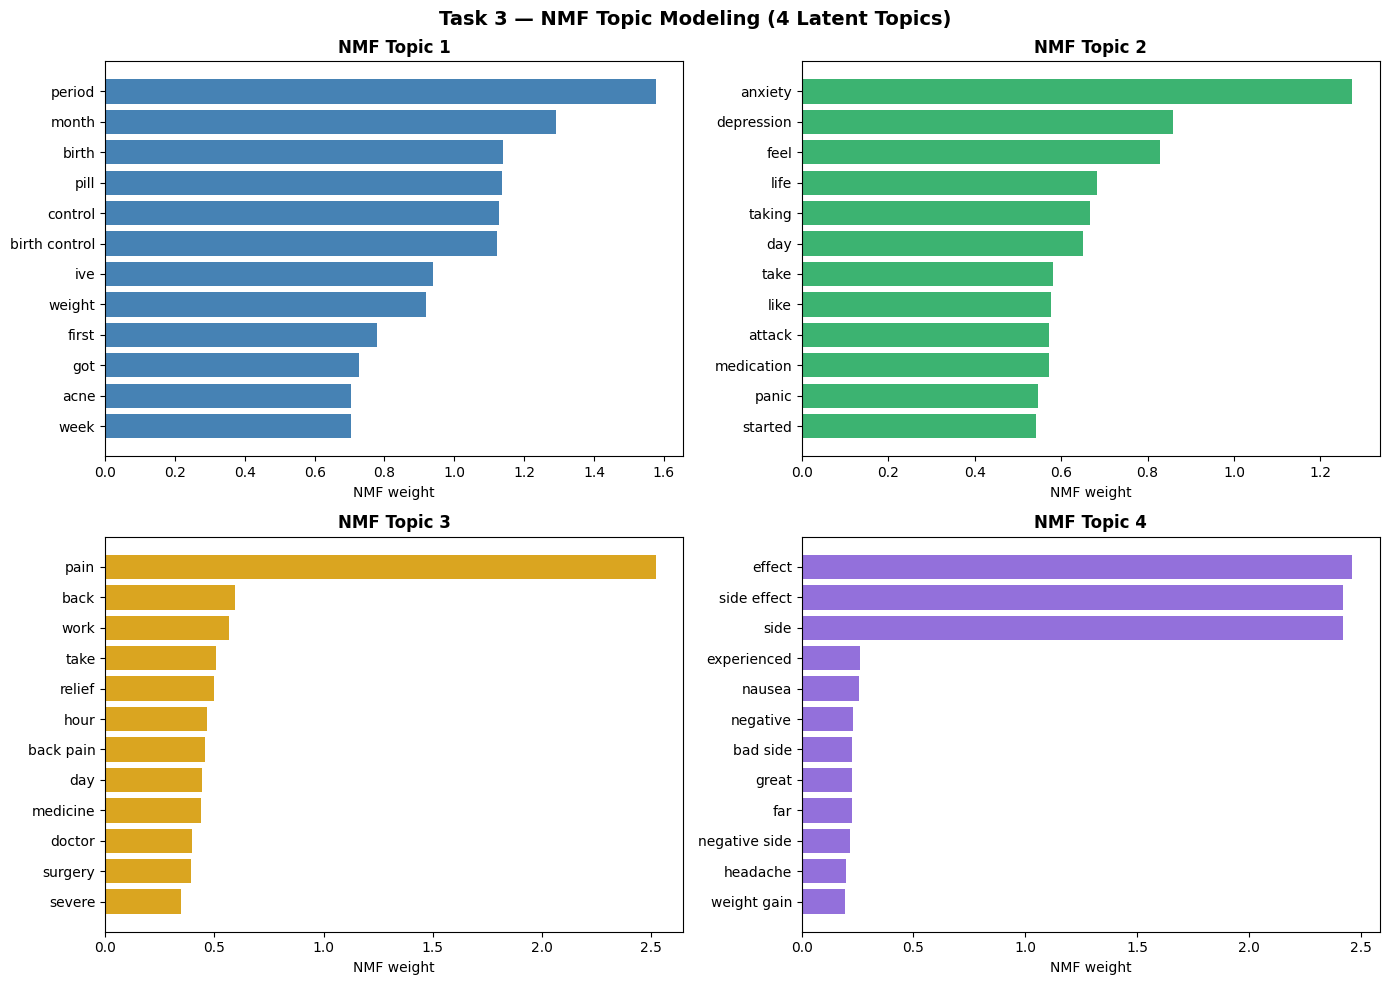

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, topic in enumerate(H):
    top_idx   = topic.argsort()[-12:][::-1]
    top_words = [feature_names[j] for j in top_idx]
    top_vals  = [topic[j] for j in top_idx]
    axes[i].barh(list(reversed(top_words)), list(reversed(top_vals)), color=THEME_COLORS[i])
    axes[i].set_title(f'NMF Topic {i+1}', fontweight='bold')
    axes[i].set_xlabel('NMF weight')

plt.suptitle('Task 3 — NMF Topic Modeling (4 Latent Topics)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('task3_nmf_topics.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Summary — All Metrics

In [13]:
print('TASK 1 — Sentiment (LinearSVC)')
print(f'  Accuracy     : {acc_s:.4f}')
print(f'  F1 Macro     : {f1_m_s:.4f}')
print(f'  AUC          : {auc:.4f}')
print(f'  Recall (neg) : {rec_neg:.4f}  <- primary metric')
print()
print('TASK 2 — Theme (LogReg Multinomial)')
print(f'  Accuracy     : {acc_t:.4f}')
print(f'  F1 Macro     : {f1_m_t:.4f}')
print()
print('TASK 3 — NMF Topic Modeling')
print(f'  Recon. error : {recon_error:.4f}')
for name, words in topics.items():
    print(f'  {name}: {chr(44)+" ".join(words[:6])}')

TASK 1 — Sentiment (LinearSVC)
  Accuracy     : 0.8681
  F1 Macro     : 0.8608
  AUC          : 0.9327
  Recall (neg) : 0.8209  <- primary metric

TASK 2 — Theme (LogReg Multinomial)
  Accuracy     : 0.9444
  F1 Macro     : 0.9071

TASK 3 — NMF Topic Modeling
  Recon. error : 226.0206
  Topic 1: ,period month birth pill control birth control
  Topic 2: ,anxiety depression feel life taking day
  Topic 3: ,pain back work take relief hour
  Topic 4: ,effect side effect side experienced nausea negative


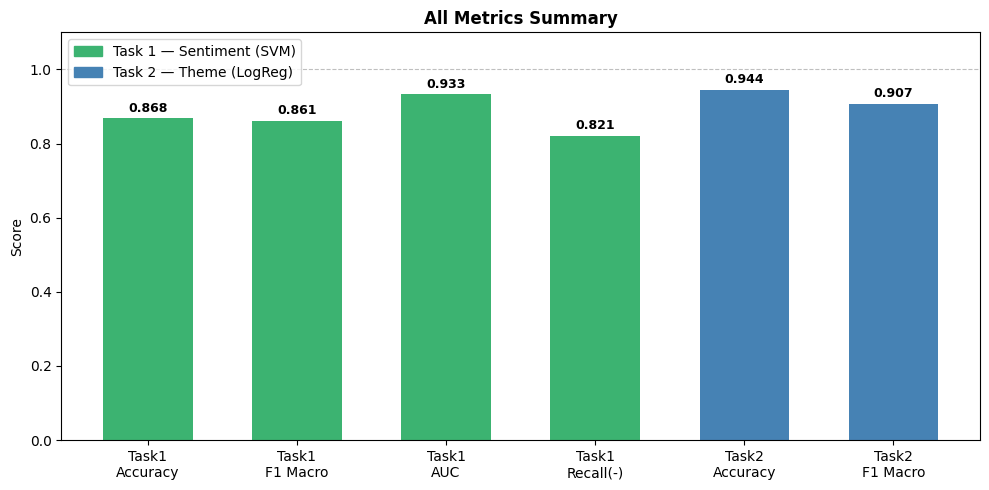

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))

metric_names  = ['Task1\nAccuracy', 'Task1\nF1 Macro', 'Task1\nAUC', 'Task1\nRecall(-)', 'Task2\nAccuracy', 'Task2\nF1 Macro']
metric_values = [acc_s, f1_m_s, auc, rec_neg, acc_t, f1_m_t]
# Green for Task 1, blue for Task 2
bar_colors    = [COLOR_POSITIVE] * 4 + [COLOR_ANXIETY] * 2

bars = ax.bar(metric_names, metric_values, color=bar_colors, width=0.6)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('All Metrics Summary', fontweight='bold')
ax.axhline(1.0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

for bar, val in zip(bars, metric_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color=COLOR_POSITIVE, label='Task 1 — Sentiment (SVM)'),
    Patch(color=COLOR_ANXIETY,  label='Task 2 — Theme (LogReg)'),
])
plt.tight_layout()
plt.savefig('all_metrics_summary.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Verify Saved Models

In [15]:
saved_svm        = joblib.load('../models/sentiment_model.pkl')
saved_vectorizer = joblib.load('../models/tfidf_vectorizer.pkl')
saved_theme      = joblib.load('../models/theme_model.pkl')

test_texts = [
    'This medication completely changed my life for the better.',
    'The side effects were unbearable and I had to stop immediately.',
    'I feel so much less anxious since starting this treatment.',
]

for text in test_texts:
    X_vec = saved_vectorizer.transform([clean_text(text)])
    sent  = 'Positive' if saved_svm.predict(X_vec)[0] == 1 else 'Negative'
    theme = saved_theme.predict(X_vec)[0]
    conf  = max(saved_theme.predict_proba(X_vec)[0])
    print(f'Text      : {text[:60]}')
    print(f'Sentiment : {sent} | Theme: {theme} ({conf*100:.0f}% confidence)')
    print()

print('Saved models verified successfully.')

Text      : This medication completely changed my life for the better.
Sentiment : Positive | Theme: Anxiety (46% confidence)

Text      : The side effects were unbearable and I had to stop immediate
Sentiment : Negative | Theme: Birth Control (56% confidence)

Text      : I feel so much less anxious since starting this treatment.
Sentiment : Positive | Theme: Depression (46% confidence)

Saved models verified successfully.


.